# MNIST Repeated vs Williamson Core Benchmark

This notebook presents the controlled MNIST comparison between repeated phase encoding and Williamson electro-optic nonlinearity.

Learning goals:

1. Read the Flax architecture for unitary repeated, subunitary repeated, and Williamson models.
2. Load the cached depth-curve benchmark.
3. Visualize accuracy, loss, insertion loss, and validation confusion matrices versus depth.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

print(f"Project root: {ROOT}")

RNG_SEED = 7

try:
    import numpy as np
    np.random.seed(RNG_SEED)
except ImportError:
    pass

print(f"Deterministic seed: {RNG_SEED}")


Project root: /Volumes/Storage/Github/Lumix
Deterministic seed: 7


## Flax Architecture

The models below use Lumix Linen modules. This is the style the tutorials should follow: the architecture is visible as a Flax `nn.Module`, and the training loop can treat each model the same way.


In [2]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from lumix.linen import InformationEncoder, IntensityReadout, SubUnitaryLinear, UnitaryLinear, WilliamsonNonlinearity

class TemperatureSoftmaxReadout(nn.Module):
    classes: int = 10
    init_gamma: float = 10.0

    @nn.compact
    def __call__(self, intensities):
        log_gamma = self.param("log_gamma", lambda key: jnp.asarray(jnp.log(self.init_gamma), dtype=jnp.float32))
        gamma = jnp.exp(log_gamma)
        logits = gamma * intensities[..., : self.classes]
        return logits, gamma

class OpticalClassifierBase(nn.Module):
    width: int = 16
    depth: int = 5
    classes: int = 10
    alpha: float = float(jnp.pi)

    def input_fields(self, x):
        amplitude = jnp.sqrt(jnp.asarray(1.0 / self.width, dtype=jnp.float32))
        return jnp.full((*x.shape[:-1], self.width), amplitude, dtype=jnp.complex64)

class UnitaryRepeatedClassifier(OpticalClassifierBase):
    @nn.compact
    def __call__(self, x, return_aux=False):
        encoder = InformationEncoder(mode="phase", normalize=False)
        phase_mask = encoder(self.alpha * x)
        fields = self.input_fields(x)
        for layer_index in range(self.depth):
            fields = UnitaryLinear(width=self.width, name=f"unitary_{layer_index}")(fields * phase_mask)
        intensities = IntensityReadout()(fields)
        logits, gamma = TemperatureSoftmaxReadout(self.classes)(intensities)
        aux = {"intensities": intensities, "gamma": gamma}
        return (logits, aux) if return_aux else logits

class UnitaryNoRepeatClassifier(OpticalClassifierBase):
    @nn.compact
    def __call__(self, x, return_aux=False):
        encoder = InformationEncoder(mode="phase", normalize=False)
        fields = self.input_fields(x) * encoder(self.alpha * x)
        for layer_index in range(self.depth):
            fields = UnitaryLinear(width=self.width, name=f"unitary_{layer_index}")(fields)
        intensities = IntensityReadout()(fields)
        logits, gamma = TemperatureSoftmaxReadout(self.classes)(intensities)
        aux = {"intensities": intensities, "gamma": gamma}
        return (logits, aux) if return_aux else logits

class SubunitaryRepeatedClassifier(OpticalClassifierBase):
    @nn.compact
    def __call__(self, x, return_aux=False):
        encoder = InformationEncoder(mode="phase", normalize=False)
        phase_mask = encoder(self.alpha * x)
        fields = self.input_fields(x)
        for layer_index in range(self.depth):
            fields = SubUnitaryLinear(width=self.width, insertion_loss_db=(0.0, 1.5), name=f"subunitary_{layer_index}")(fields * phase_mask)
        intensities = IntensityReadout()(fields)
        logits, gamma = TemperatureSoftmaxReadout(self.classes)(intensities)
        aux = {"intensities": intensities, "gamma": gamma}
        return (logits, aux) if return_aux else logits

class WilliamsonClassifier(OpticalClassifierBase):
    @nn.compact
    def __call__(self, x, return_aux=False):
        encoder = InformationEncoder(mode="phase", normalize=False)
        phase_mask = encoder(self.alpha * x)
        fields = self.input_fields(x) * phase_mask
        for layer_index in range(self.depth):
            fields = UnitaryLinear(width=self.width, name=f"unitary_{layer_index}")(fields)
            fields = WilliamsonNonlinearity(tap=0.1, gain=0.05 * jnp.pi, bias=0.5 * jnp.pi, train_gain=True, train_bias=True, name=f"williamson_{layer_index}")(fields)
        intensities = IntensityReadout()(fields)
        logits, gamma = TemperatureSoftmaxReadout(self.classes)(intensities)
        aux = {"intensities": intensities, "gamma": gamma}
        return (logits, aux) if return_aux else logits

sample = jnp.ones((2, 16), dtype=jnp.float32) * 0.5
for cls in [UnitaryRepeatedClassifier, UnitaryNoRepeatClassifier, SubunitaryRepeatedClassifier, WilliamsonClassifier]:
    model = cls(depth=2)
    variables = model.init(jax.random.key(RNG_SEED), sample)
    logits, aux = model.apply(variables, sample, return_aux=True)
    print(cls.__name__, "logits", logits.shape, "gamma", float(aux["gamma"]))


UnitaryRepeatedClassifier logits (2, 10) gamma 10.0
UnitaryNoRepeatClassifier logits (2, 10) gamma 10.0


SubunitaryRepeatedClassifier logits (2, 10) gamma 10.0
WilliamsonClassifier logits (2, 10) gamma 10.0


## Train or Load the Notebook-Owned Benchmark Cache

The cell below is self-contained. It defines the dataset loader, minibatching, training loop, insertion-loss metric, configs, and tqdm monitoring in the notebook. It uses Lumix layers, JAX, Flax, Optax, NumPy, and tqdm only.


In [3]:
import json
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from lumix.metrics import accuracy
from lumix.losses import cross_entropy_logits

NOTEBOOK_DIR = ROOT / "notebooks" / "repeated_encoding_tutorials"
CACHE_DIR = NOTEBOOK_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATASET_CACHE = CACHE_DIR / f"mnist_pca16_phase_no_clip_rng{RNG_SEED}.npz"
BENCHMARK_CACHE = CACHE_DIR / f"mnist_three_way_depth_curve_rng{RNG_SEED}.json"
NO_REPEAT_BENCHMARK_CACHE = CACHE_DIR / f"mnist_no_repeat_depth_curve_rng{RNG_SEED}.json"
BENCHMARK_CACHE_VERSION = 2
RAW_MNIST_CACHE = CACHE_DIR / "mnist_raw.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
WIDTH = 16
NUM_CLASSES = 10
EPOCHS = 300
BATCH_SIZE = 500
LEARNING_RATE = 5e-3
FORCE_REGENERATE_BENCHMARK = False

@dataclass(frozen=True)
class BenchmarkConfig:
    name: str
    kind: str
    depth: int


def one_hot(labels, classes=NUM_CLASSES):
    return np.eye(classes, dtype=np.float32)[labels]

def download_mnist():
    if RAW_MNIST_CACHE.exists():
        return
    urllib.request.urlretrieve(MNIST_URL, RAW_MNIST_CACHE)

def fit_pca_phase_features_no_clip(train_images, test_images, width=WIDTH):
    train_flat = train_images.reshape(train_images.shape[0], -1).astype(np.float32) / 255.0
    test_flat = test_images.reshape(test_images.shape[0], -1).astype(np.float32) / 255.0
    pixel_mean = train_flat.mean(axis=0, keepdims=True)
    train_centered = train_flat - pixel_mean
    test_centered = test_flat - pixel_mean
    covariance = (train_centered.T @ train_centered) / train_centered.shape[0]
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    selected = order[:width]
    components = eigenvectors[:, selected].astype(np.float32)
    explained_variance = (eigenvalues[selected] / eigenvalues.sum()).astype(np.float32)
    train_scores = train_centered @ components
    test_scores = test_centered @ components
    score_mean = train_scores.mean(axis=0, keepdims=True)
    score_std = np.where(train_scores.std(axis=0, keepdims=True) == 0.0, 1.0, train_scores.std(axis=0, keepdims=True))
    train_standardized = (train_scores - score_mean) / score_std
    test_standardized = (test_scores - score_mean) / score_std
    train_min = train_standardized.min(axis=0, keepdims=True)
    train_max = train_standardized.max(axis=0, keepdims=True)
    train_range = np.where(train_max == train_min, 1.0, train_max - train_min)
    x_train = ((train_standardized - train_min) / train_range).astype(np.float32)
    x_test = ((test_standardized - train_min) / train_range).astype(np.float32)
    return x_train, x_test, explained_variance

def load_or_create_dataset():
    if DATASET_CACHE.exists():
        cached = np.load(DATASET_CACHE)
        return cached["x_train"], cached["y_train"], cached["x_test"], cached["y_test"]
    download_mnist()
    raw = np.load(RAW_MNIST_CACHE)
    x_train, x_test, explained_variance = fit_pca_phase_features_no_clip(raw["x_train"], raw["x_test"])
    y_train = one_hot(raw["y_train"])
    y_test = one_hot(raw["y_test"])
    np.savez_compressed(
        DATASET_CACHE,
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        explained_variance=explained_variance,
        rng_seed=np.asarray(RNG_SEED),
        source="notebook:03_mnist_repeated_vs_williamson:self_contained",
    )
    return x_train, y_train, x_test, y_test

def iterate_batches(x, y, batch_size, rng_key):
    indices = jax.random.permutation(rng_key, x.shape[0])
    for start in range(0, x.shape[0], batch_size):
        batch_indices = indices[start:start + batch_size]
        yield x[batch_indices], y[batch_indices]

def power_loss_db(intensities):
    total_power = jnp.sum(intensities, axis=-1)
    return -10.0 * jnp.log10(jnp.clip(total_power, 1e-12, None))

def confusion_matrix(true_labels, predicted_labels, classes=NUM_CLASSES):
    matrix = np.zeros((classes, classes), dtype=np.int32)
    np.add.at(matrix, (true_labels, predicted_labels), 1)
    return matrix

def cache_has_confusion_matrices(payload):
    if payload.get("cache_version") != BENCHMARK_CACHE_VERSION:
        return False
    return all("val_confusion_matrix" in row for row in payload.get("results", []))

def build_model(kind, depth):
    if kind == "repeated_phase":
        return UnitaryRepeatedClassifier(depth=depth)
    if kind == "no_repeat_phase":
        return UnitaryNoRepeatClassifier(depth=depth)
    if kind == "repeated_subunitary":
        return SubunitaryRepeatedClassifier(depth=depth)
    if kind == "williamson":
        return WilliamsonClassifier(depth=depth)
    raise ValueError(kind)

def count_params(params):
    return int(sum(leaf.size for leaf in jax.tree_util.tree_leaves(params)))

def run_config(config, data):
    train_x, train_y_np, test_x, test_y_np = data
    train_x = jnp.asarray(train_x)
    train_y = jnp.asarray(train_y_np)
    test_x = jnp.asarray(test_x)
    test_y = jnp.asarray(test_y_np)
    model = build_model(config.kind, config.depth)
    params = model.init(jax.random.key(RNG_SEED), train_x[:8])["params"]
    optimizer = optax.adam(LEARNING_RATE)
    opt_state = optimizer.init(params)

    def loss_fn(optical_params, batch_x, batch_y):
        logits = model.apply({"params": optical_params}, batch_x)
        return cross_entropy_logits(batch_y, logits), logits

    @jax.jit
    def train_step(optical_params, state, batch_x, batch_y):
        (loss_value, logits), grads = jax.value_and_grad(loss_fn, has_aux=True)(optical_params, batch_x, batch_y)
        updates, state = optimizer.update(grads, state, optical_params)
        return optax.apply_updates(optical_params, updates), state, loss_value, accuracy(batch_y, logits)

    @jax.jit
    def eval_step(optical_params, eval_x, eval_y):
        logits, aux = model.apply({"params": optical_params}, eval_x, return_aux=True)
        return (
            cross_entropy_logits(eval_y, logits),
            accuracy(eval_y, logits),
            aux["gamma"],
            jnp.mean(power_loss_db(aux["intensities"])),
            jnp.min(power_loss_db(aux["intensities"])),
            jnp.max(power_loss_db(aux["intensities"])),
        )

    @jax.jit
    def predict_step(optical_params, eval_x):
        logits = model.apply({"params": optical_params}, eval_x)
        return jnp.argmax(logits, axis=-1)

    rng = jax.random.key(RNG_SEED)
    history = []
    progress = tqdm(range(1, EPOCHS + 1), desc=config.name, leave=False)
    for epoch in progress:
        rng, epoch_rng = jax.random.split(rng)
        losses = []
        scores = []
        for batch_x, batch_y in iterate_batches(train_x, train_y, BATCH_SIZE, epoch_rng):
            params, opt_state, loss_value, score = train_step(params, opt_state, batch_x, batch_y)
            losses.append(loss_value)
            scores.append(score)
        if epoch == 1 or epoch % 50 == 0 or epoch == EPOCHS:
            val_loss, val_acc, gamma, mean_il, min_il, max_il = eval_step(params, test_x, test_y)
            progress.set_postfix(val_acc=f"{float(val_acc):.3f}", val_loss=f"{float(val_loss):.3f}")
            history.append({"epoch": epoch, "val_accuracy": float(val_acc), "val_loss": float(val_loss)})

    train_loss, train_acc, _, train_mean_il, _, _ = eval_step(params, train_x, train_y)
    val_loss, val_acc, gamma, mean_il, min_il, max_il = eval_step(params, test_x, test_y)
    val_predictions = np.asarray(predict_step(params, test_x), dtype=np.int32)
    val_targets = np.asarray(np.argmax(test_y_np, axis=1), dtype=np.int32)
    val_confusion = confusion_matrix(val_targets, val_predictions)
    return {
        "name": config.name,
        "kind": config.kind,
        "layers": config.depth,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "rng_seed": RNG_SEED,
        "final_logit_scale": float(gamma),
        "train_accuracy": float(train_acc),
        "val_accuracy": float(val_acc),
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "train_mean_insertion_loss_db": float(train_mean_il),
        "val_mean_insertion_loss_db": float(mean_il),
        "val_min_insertion_loss_db": float(min_il),
        "val_max_insertion_loss_db": float(max_il),
        "val_confusion_matrix": val_confusion.tolist(),
        "stored_param_count": count_params(params),
        "history": history,
    }

regenerate_benchmark = FORCE_REGENERATE_BENCHMARK or not BENCHMARK_CACHE.exists()
if BENCHMARK_CACHE.exists() and not FORCE_REGENERATE_BENCHMARK:
    payload = json.loads(BENCHMARK_CACHE.read_text())
    regenerate_benchmark = not cache_has_confusion_matrices(payload)
    if regenerate_benchmark:
        print("Existing benchmark cache lacks validation confusion matrices; regenerating it.")
    else:
        results = payload["results"]
        print(f"Loaded notebook-owned benchmark cache: {BENCHMARK_CACHE.relative_to(ROOT)}")

if regenerate_benchmark:
    data = load_or_create_dataset()
    configs = []
    for depth in range(1, 6):
        configs.extend([
            BenchmarkConfig(f"unitary-repeated-depth{depth}", "repeated_phase", depth),
            BenchmarkConfig(f"subunitary-repeated-depth{depth}", "repeated_subunitary", depth),
            BenchmarkConfig(f"williamson-depth{depth}", "williamson", depth),
        ])
    results = [run_config(config, data) for config in tqdm(configs, desc="model configs")]
    payload = {
        "source": "notebook:03_mnist_repeated_vs_williamson:self_contained",
        "cache_version": BENCHMARK_CACHE_VERSION,
        "rng_seed": RNG_SEED,
        "results": results,
    }
    BENCHMARK_CACHE.write_text(json.dumps(payload, indent=2) + "\n")
    print(f"Wrote notebook-owned benchmark cache: {BENCHMARK_CACHE.relative_to(ROOT)}")

print(f"Benchmark rows: {len(results)}")
labels = {"repeated_phase": "Unitary repeated", "repeated_subunitary": "Subunitary repeated", "williamson": "Williamson"}
for row in results[:3]:
    print(row["name"], row["val_accuracy"], row["val_loss"])

if NO_REPEAT_BENCHMARK_CACHE.exists() and not FORCE_REGENERATE_BENCHMARK:
    no_repeat_payload = json.loads(NO_REPEAT_BENCHMARK_CACHE.read_text())
    no_repeat_results = no_repeat_payload["results"]
    print(f"Loaded notebook-owned no-repeat baseline cache: {NO_REPEAT_BENCHMARK_CACHE.relative_to(ROOT)}")
else:
    data = load_or_create_dataset()
    no_repeat_configs = [
        BenchmarkConfig(f"no-repeat-unitary-depth{depth}", "no_repeat_phase", depth)
        for depth in range(1, 6)
    ]
    no_repeat_results = [run_config(config, data) for config in tqdm(no_repeat_configs, desc="no-repeat configs")]
    no_repeat_payload = {
        "source": "notebook:03_mnist_repeated_vs_williamson:no_repeat_baseline",
        "cache_version": BENCHMARK_CACHE_VERSION,
        "rng_seed": RNG_SEED,
        "results": no_repeat_results,
    }
    NO_REPEAT_BENCHMARK_CACHE.write_text(json.dumps(no_repeat_payload, indent=2) + "\n")
    print(f"Wrote notebook-owned no-repeat baseline cache: {NO_REPEAT_BENCHMARK_CACHE.relative_to(ROOT)}")
print(f"No-repeat baseline rows: {len(no_repeat_results)}")


Loaded notebook-owned benchmark cache: notebooks/repeated_encoding_tutorials/cache/mnist_three_way_depth_curve_rng7.json
Benchmark rows: 15
unitary-repeated-depth1 0.8624999523162842 0.44308847188949585
subunitary-repeated-depth1 0.8693000078201294 0.4249418377876282
williamson-depth1 0.8622999787330627 0.441029816865921
Loaded notebook-owned no-repeat baseline cache: notebooks/repeated_encoding_tutorials/cache/mnist_no_repeat_depth_curve_rng7.json
No-repeat baseline rows: 5


/Volumes/Storage/Github/Lumix/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Single Sample PCA16 Encoding


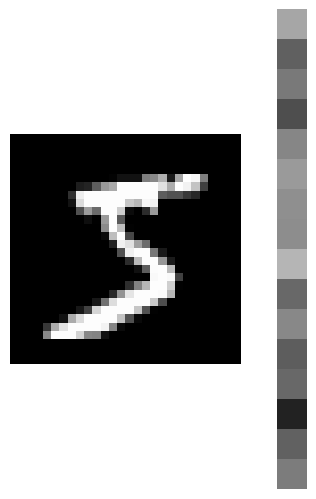

In [4]:
sample_index = 0
download_mnist()
if not DATASET_CACHE.exists():
    load_or_create_dataset()

raw_mnist = np.load(RAW_MNIST_CACHE)
pca_cache = np.load(DATASET_CACHE)
raw_image = raw_mnist["x_train"][sample_index]
pca16_column = pca_cache["x_train"][sample_index].reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(3.2, 4.8), gridspec_kw={"width_ratios": [3, 1]})
axes[0].imshow(raw_image, cmap="gray")
axes[0].axis("off")

axes[1].imshow(pca16_column, cmap="gray", vmin=0.0, vmax=1.0, aspect="equal")
axes[1].axis("off")
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.08)
plt.show()


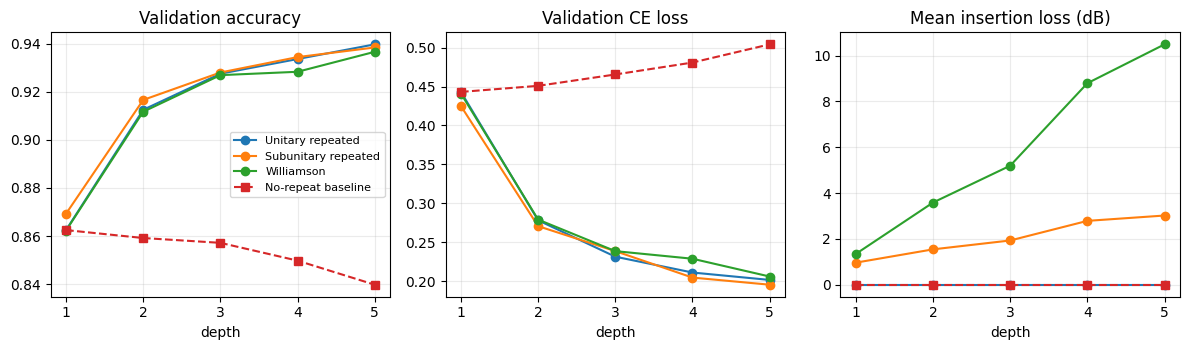

In [5]:
def series(kind, key):
    rows = sorted([row for row in results if row["kind"] == kind], key=lambda row: row["layers"])
    return np.array([row["layers"] for row in rows]), np.array([row[key] for row in rows])

def baseline_series(key):
    rows = sorted(no_repeat_results, key=lambda row: row["layers"])
    return np.array([row["layers"] for row in rows]), np.array([row[key] for row in rows])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=False)
plots = [
    ("val_accuracy", "Validation accuracy"),
    ("val_loss", "Validation CE loss"),
    ("val_mean_insertion_loss_db", "Mean insertion loss (dB)"),
]
for ax, (key, title) in zip(axes, plots):
    for kind, label in labels.items():
        depth, values = series(kind, key)
        ax.plot(depth, values, marker="o", label=label)
    depth, values = baseline_series(key)
    ax.plot(depth, values, marker="s", linestyle="--", label="No-repeat baseline")
    ax.set_title(title)
    ax.set_xlabel("depth")
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Validation Confusion Matrices


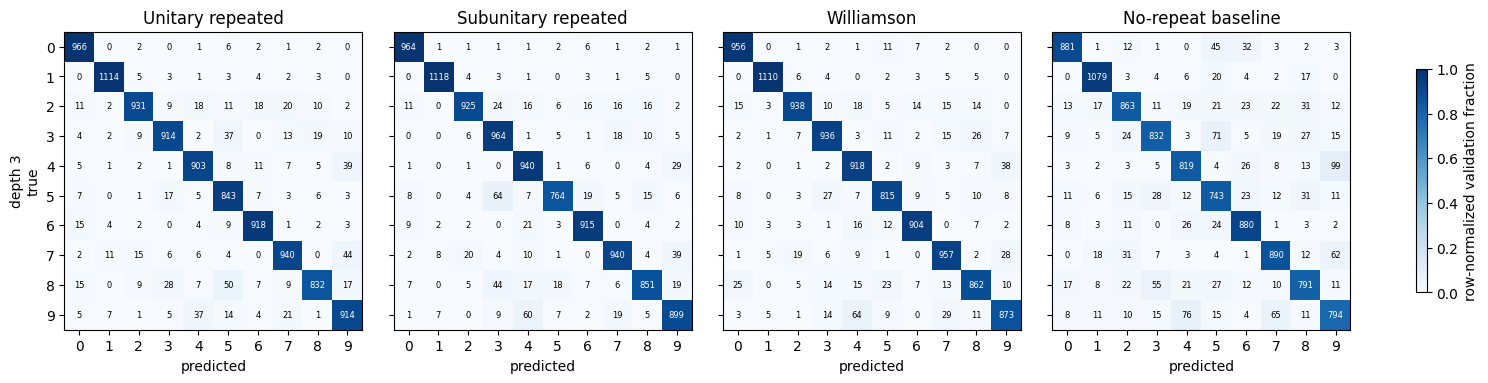

In [6]:
confusion_rows = results + no_repeat_results
missing_confusion = [row["name"] for row in confusion_rows if "val_confusion_matrix" not in row]
if missing_confusion:
    raise RuntimeError(
        "Benchmark results do not include validation confusion matrices. "
        "Run the train/load benchmark cell again so it regenerates the cache."
    )

target_depth = 3
confusion_cases = [
    ("repeated_phase", "Unitary repeated"),
    ("repeated_subunitary", "Subunitary repeated"),
    ("williamson", "Williamson"),
    ("no_repeat_phase", "No-repeat baseline"),
]
result_by_case = {(row["kind"], row["layers"]): row for row in confusion_rows}

fig, axes = plt.subplots(
    1,
    len(confusion_cases),
    figsize=(15, 3.6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = np.asarray(axes).reshape(len(confusion_cases))

image = None
for ax, (kind, title) in zip(axes, confusion_cases):
    row = result_by_case[(kind, target_depth)]
    counts = np.asarray(row["val_confusion_matrix"], dtype=np.int32)
    totals = counts.sum(axis=1, keepdims=True)
    normalized = np.divide(counts, totals, out=np.zeros_like(counts, dtype=np.float32), where=totals != 0)
    image = ax.imshow(normalized, cmap="Blues", vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xlabel("predicted")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    for true_label in range(NUM_CLASSES):
        for predicted_label in range(NUM_CLASSES):
            value = int(counts[true_label, predicted_label])
            text_color = "white" if normalized[true_label, predicted_label] > 0.5 else "black"
            ax.text(predicted_label, true_label, value, ha="center", va="center", fontsize=6, color=text_color)

axes[0].set_ylabel(f"depth {target_depth}\ntrue")
fig.colorbar(image, ax=axes, shrink=0.75, label="row-normalized validation fraction")
plt.show()


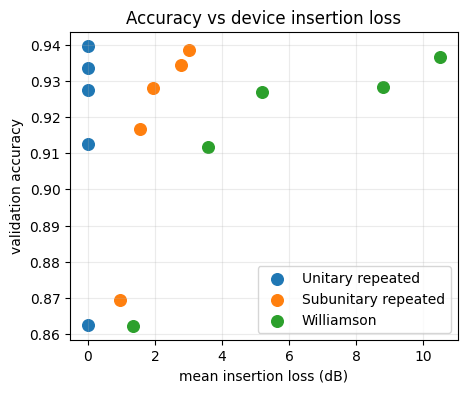

In [7]:
plt.figure(figsize=(5, 4))
for kind, label in labels.items():
    _, acc = series(kind, "val_accuracy")
    _, il = series(kind, "val_mean_insertion_loss_db")
    plt.scatter(il, acc, label=label, s=70)
plt.xlabel("mean insertion loss (dB)")
plt.ylabel("validation accuracy")
plt.title("Accuracy vs device insertion loss")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## Interpretation

The repeated models are competitive with Williamson while requiring much lower device insertion loss. The unitary repeated model has essentially zero optical loss; the subunitary model trades several dB of loss for a regularized optical transform; Williamson reaches similar accuracy at depth 5 but with much larger insertion loss.

Exercise: identify the depth where Williamson has its best accuracy, then compare its insertion loss to the repeated models at the same depth.
